## Ancel Keys - Project 2 Final Code

Our project compares the diets of two different islands in Hawai'i: Oahu and Moloka'i. Oahu's role as the biggest tourist island in Hawai'i as well as the most urbanized has resulted in a rapid change to the diet as it quickly shifted towards hyper-processed western convenience foods.
On the other hand, Moloka'i is a smaller island that has mostly retained the traditional Hawaiian diet -- fresh, raw, healthier foods.

In [1]:
import pandas as pd
import numpy as np
import requests

In [2]:
# turn sheet into df
columns = [
    "Nutrition", "Source",
    "C_1_3",
    "F_4_8", "M_4_8",
    "F_9_13", "M_9_13",
    "F_14_18", "M_14_18",
    "F_19_30", "M_19_30",
    "F_31_50", "M_31_50",
    "F_51_plus", "M_51_plus"
]

data = [
    ["Energy","---",1000,1200,1400,1600,1800,1800,2200,2000,2400,1800,2200,1600,2000],
    ["Protein","RDA",13,19,19,34,34,46,52,46,56,46,56,46,56],
    ["Fiber","---",14,16.8,19.6,22.4,25.2,25.2,30.8,28,33.6,25.2,30.8,22.4,28],
    ["Folate","RDA",150,200,200,300,300,400,400,400,400,400,400,400,400],
    ["Calcium","RDA",700,1000,1000,1300,1300,1300,1300,1000,1000,1000,1000,1200,1000],
    ["Carbohydrate","RDA",130,130,130,130,130,130,130,130,130,130,130,130,130],
    ["Iron","RDA",7,10,10,8,8,15,11,18,8,18,8,8,8],
    ["Magnesium","RDA",80,130,130,240,240,360,410,310,400,320,420,320,420],
    ["Niacin","RDA",6,8,8,12,12,14,16,14,16,14,16,14,16],
    ["Phosphorus","RDA",460,500,500,1250,1250,1250,1250,700,700,700,700,700,700],
    ["Potassium","AI",3000,3800,3800,4500,4500,4700,4700,4700,4700,4700,4700,4700,4700],
    ["Riboflavin","RDA",0.5,0.6,0.6,0.9,0.9,1,1.3,1.1,1.3,1.1,1.3,1.1,1.3],
    ["Thiamin","RDA",0.5,0.6,0.6,0.9,0.9,1,1.2,1.1,1.2,1.1,1.2,1.1,1.2],
    ["Vitamin_A","RDA",300,400,400,600,600,700,900,700,900,700,900,700,900],
    ["Vitamin_B12","RDA",0.9,1.2,1.2,1.8,1.8,2.4,2.4,2.4,2.4,2.4,2.4,2.4,2.4],
    ["Vitamin_B6","RDA",0.5,0.6,0.6,1,1,1.2,1.3,1.3,1.3,1.3,1.3,1.5,1.7],
    ["Vitamin_C","RDA",15,25,25,45,45,65,75,75,90,75,90,75,90],
    ["Vitamin_E","RDA",6,7,7,11,11,15,15,15,15,15,15,15,15],
    ["Vitamin_K","AI",30,55,55,60,60,75,75,90,120,90,120,90,120],
    ["Zinc","RDA",3,5,5,8,8,9,11,8,11,8,11,8,11]
]

# need to map names to fix later issues
dri_name_map = {
    "Fiber": "Fiber, total dietary",
    "Folate": "Folate, DFE",
    "Carbohydrate": "Carbohydrate, by difference",
    "Iron": "Iron, Fe",
    "Magnesium": "Magnesium, Mg",
    "Phosphorus": "Phosphorus, P",
    "Potassium": "Potassium, K",
    "Vitamin_A": "Vitamin A, RAE",
    "Vitamin_B12": "Vitamin B-12",
    "Vitamin_B6": "Vitamin B-6",
    "Vitamin_C": "Vitamin C, total ascorbic acid",
    "Vitamin_E": "Vitamin E (alpha-tocopherol)",
    "Vitamin_K": "Vitamin K (phylloquinone)",
    "Zinc": "Zinc, Zn",
    "Calcium": "Calcium, Ca"
}

dri_df = pd.DataFrame(data, columns=columns)

dri_df["Nutrition"] = dri_df["Nutrition"].replace(dri_name_map)

In [3]:
# need to map age and sex to correct columns for the DRI function
def age_sex_column(age, sex):
    
    if age <= 3:
        return "C_1_3"
    elif age <= 8:
        return f"{sex}_4_8"
    elif age <= 13:
        return f"{sex}_9_13"
    elif age <= 18:
        return f"{sex}_14_18"
    elif age <= 30:
        return f"{sex}_19_30"
    elif age <= 50:
        return f"{sex}_31_50"
    else:
        return f"{sex}_51_plus"

In [4]:
def get_dri(age, sex):
    col = age_sex_column(age, sex)
    
    if col not in dri_df.columns:
        raise ValueError("Invalid age/sex combination")
    
    result = dri_df.set_index("Nutrition")[col]
    
    return result

In [8]:
# Dietary Reference Intake (DRI) function
# Use "M" or "F" for male or female respectively
get_dri(28, "M")

Nutrition
Energy                            2400.0
Protein                             56.0
Fiber, total dietary                33.6
Folate, DFE                        400.0
Calcium, Ca                       1000.0
Carbohydrate, by difference        130.0
Iron, Fe                             8.0
Magnesium, Mg                      400.0
Niacin                              16.0
Phosphorus, P                      700.0
Potassium, K                      4700.0
Riboflavin                           1.3
Thiamin                              1.2
Vitamin A, RAE                     900.0
Vitamin B-12                         2.4
Vitamin B-6                          1.3
Vitamin C, total ascorbic acid      90.0
Vitamin E (alpha-tocopherol)        15.0
Vitamin K (phylloquinone)          120.0
Zinc, Zn                            11.0
Name: M_19_30, dtype: float64

In [11]:
foods_to_search = [
    #  Diet Moloka'i
    169308,	#Taro, raw (kalo)
    170431,	#Poi (fermented taro paste)
    2346404,	#Sweet potato, raw (ʻuala)
    171714,	#Breadfruit, raw (ʻulu)
    2747673,	#Fish, ahi/tuna raw
    171959,	#Fish, mahi-mahi (dolphinfish), raw
    173676,	#Fish, opah (moonfish), raw
    170090,	#Seaweed, agar, dried
    170169,	#Coconut meat, raw
    173944,	#Banana, raw 
    169926,	#Papaya, raw
    171477,	#Chicken, whole, raw (kalua-style)
    2195577,	#Pork, shoulder, raw (kalua pork base)
    169303,	#Sweet potato leaves, raw

    # Diet Oahu
    1927473,	#Spam, classic (canned pork)
    168878,	#White rice, cooked (calrose)
    169839,	#Macaroni salad (restaurant-style)
    2706930,	#Hamburger patty, fast food (Big Mac-style)
    170698,	#French fries, fast food
    2706093,	#Chicken nuggets, fast food
    2708615,	#Pizza, cheese, frozen/fast food
    174852,	#Soda, cola (Coca-Cola)
    2707598,	#Bread, white sandwich loaf
    748967,	#Eggs, large, raw (whole)
    2705385,	#Milk, whole, fluid
    2708453,	#Breakfast cereal, corn flakes
    2089505,	#Hot dog / frankfurter
    2705630,	#Ice cream, vanilla
    2709422	#Potato chips, plain
]

In [12]:
apikey = "uOgTaIqGwW8Of1b6UcucKDg1yWcBt01FPea0hqDT"

def get_food_data(fdc_id):
    url = f"https://api.nal.usda.gov/fdc/v1/food/{fdc_id}"
    params = {"api_key": apikey}
    response = requests.get(url, params=params)

    if response.status_code != 200:
        print("Error retrieving food:", fdc_id)
        return None

    food = response.json()

    row = {
        "fdcId": fdc_id,
        "Food": food.get("description", "Unknown")
    }

    for nutrient in food["foodNutrients"]:

        nid = nutrient["nutrient"]["id"]

        if nid in important_nutrients:
            name = important_nutrients[nid]
            row[name] = nutrient.get("amount", 0)

    return row

In [13]:
important_nutrients = {
    1008: "Energy",
    1003: "Protein",
    1005: "Carbohydrate, by difference",
    1079: "Fiber, total dietary",
    1087: "Calcium, Ca",
    1089: "Iron, Fe",
    1092: "Potassium, K",
    1162: "Vitamin C, total ascorbic acid",
    1090: "Magnesium, Mg",
    1095: "Zinc, Zn",
    1091: "Phosphorus, P",
    1165: "Thiamin",
    1166: "Riboflavin",
    1167: "Niacin",
    1177: "Folate, DFE",
    1106: "Vitamin A, RAE",
    1178: "Vitamin B-12",
    1175: "Vitamin B-6",
    1109: "Vitamin E (alpha-tocopherol)",
    1185: "Vitamin K (phylloquinone)",
    1093: "Sodium, Na"
}


def extract_nutrients(food_item):
    nutrients = {v: 0 for v in important_nutrients.values()}
    
    for n in food_item["foodNutrients"]:
        if n["nutrientId"] in important_nutrients:
            nutrients[important_nutrients[n["nutrientId"]]] = n["value"]
    
    return nutrients

In [14]:
rows = []

for fdc in foods_to_search:
    row = get_food_data(fdc)

    if row is not None:
        rows.append(row)

food_df = pd.DataFrame(rows)
food_df = food_df.set_index("Food")
food_df = food_df.fillna(0)

food_df.to_csv("hawaii_food_nutrients.csv")
food_df = pd.read_csv("hawaii_food_nutrients.csv", index_col="Food")

food_df

Error retrieving food: 748967


,fdcId,Energy,Protein,"Carbohydrate, by difference","Fiber, total dietary","Calcium, Ca","Iron, Fe","Magnesium, Mg","Phosphorus, P","Potassium, K",...,"Vitamin C, total ascorbic acid",Thiamin,Riboflavin,Niacin,Vitamin B-6,"Folate, DFE",Vitamin B-12,"Vitamin A, RAE",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone)
Food,,,,,,,,,,,,,,,,,,,,,
"Taro, raw",169308,112.0,1.500000,26.460000,4.1,43.000,0.5500,33.00,84.00,591.0,...,4.50,0.095,0.025,0.6000,0.2830,22.0,0.000,4.0,2.38,1.0
Poi,170431,112.0,0.380000,27.230000,0.4,16.000,0.8800,24.00,39.00,183.0,...,4.00,0.130,0.040,1.1000,0.2730,21.0,0.000,3.0,2.30,1.0
"Sweet potatoes, orange flesh, without skin, raw",2346404,0.0,1.578125,17.327875,0.0,22.330,0.3980,19.14,36.73,486.4,...,14.84,0.045,0.000,0.4325,0.1241,0.0,0.000,0.0,0.00,0.2
"Breadfruit, raw",171714,103.0,1.070000,27.120000,4.9,17.000,0.5400,25.00,30.00,490.0,...,29.00,0.110,0.030,0.9000,0.1000,14.0,0.000,0.0,0.10,0.5
"Tuna, ahi or yellowfin, frozen, wild caught",2747673,0.0,24.700000,-0.104500,0.0,3.193,0.5914,35.48,270.80,420.2,...,0.00,0.000,0.000,0.0000,0.0000,0.0,1.374,0.0,0.00,0.0
"Fish, mahimahi, raw",171959,85.0,18.500000,0.000000,0.0,15.000,1.1300,30.00,143.00,416.0,...,0.00,0.020,0.070,6.1000,0.4000,5.0,0.600,54.0,0.00,0.0
"Fish, monkfish, raw",173676,76.0,14.480000,0.000000,0.0,8.000,0.3200,21.00,200.00,400.0,...,1.00,0.025,0.060,2.1000,0.2400,7.0,0.900,12.0,0.00,0.0
"Seaweed, agar, dried",170090,306.0,6.210000,80.880000,7.7,625.000,21.4000,770.00,52.00,1125.0,...,0.00,0.010,0.222,0.2020,0.3030,580.0,0.000,0.0,5.00,24.4
"Nuts, coconut meat, raw",170169,354.0,3.330000,15.230000,9.0,14.000,2.4300,32.00,113.00,356.0,...,3.30,0.066,0.020,0.5400,0.0540,26.0,0.000,0.0,0.24,0.2


In [15]:
# add prices to food_df and categorize molokai and oahu
# prices are per 100g

molokai_prices = {
    169308: 0.55,
    170431: 1.32,
    2346404: 0.42,
    171714: 0.77,
    2747673: 3.30,
    171959: 2.86,
    173676: 3.75,
    170090: 15.86,
    170169: 0.57,
    173944: 0.20,
    169926: 0.33,
    171477: 0.55,
    2195577: 0.77,
    169303: 1.10
}

oahu_prices = {
    1927473: 1.26,
    168878: 0.33,
    169839: 1.10,
    2706930: 2.50,
    170698: 2.98,
    2706093: 3.70,
    2708615: 2.00,
    174852: 0.35,
    2707598: 0.88,
    748967: 0.92,
    2705385: 0.20,
    2708453: 1.30,
    2089505: 0.94,
    2705630: 0.79,
    2709422: 2.20
}

food_df["Prices"] = food_df["fdcId"].map(
    lambda x: molokai_prices.get(x, oahu_prices.get(x)))

food_df["Diet_Type"] = food_df["fdcId"].map(
    lambda x: "Molokai" if x in molokai_prices else "Oahu")

food_df

,fdcId,Energy,Protein,"Carbohydrate, by difference","Fiber, total dietary","Calcium, Ca","Iron, Fe","Magnesium, Mg","Phosphorus, P","Potassium, K",...,Riboflavin,Niacin,Vitamin B-6,"Folate, DFE",Vitamin B-12,"Vitamin A, RAE",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),Prices,Diet_Type
Food,,,,,,,,,,,,,,,,,,,,,
"Taro, raw",169308,112.0,1.500000,26.460000,4.1,43.000,0.5500,33.00,84.00,591.0,...,0.025,0.6000,0.2830,22.0,0.000,4.0,2.38,1.0,0.55,Molokai
Poi,170431,112.0,0.380000,27.230000,0.4,16.000,0.8800,24.00,39.00,183.0,...,0.040,1.1000,0.2730,21.0,0.000,3.0,2.30,1.0,1.32,Molokai
"Sweet potatoes, orange flesh, without skin, raw",2346404,0.0,1.578125,17.327875,0.0,22.330,0.3980,19.14,36.73,486.4,...,0.000,0.4325,0.1241,0.0,0.000,0.0,0.00,0.2,0.42,Molokai
"Breadfruit, raw",171714,103.0,1.070000,27.120000,4.9,17.000,0.5400,25.00,30.00,490.0,...,0.030,0.9000,0.1000,14.0,0.000,0.0,0.10,0.5,0.77,Molokai
"Tuna, ahi or yellowfin, frozen, wild caught",2747673,0.0,24.700000,-0.104500,0.0,3.193,0.5914,35.48,270.80,420.2,...,0.000,0.0000,0.0000,0.0,1.374,0.0,0.00,0.0,3.30,Molokai
"Fish, mahimahi, raw",171959,85.0,18.500000,0.000000,0.0,15.000,1.1300,30.00,143.00,416.0,...,0.070,6.1000,0.4000,5.0,0.600,54.0,0.00,0.0,2.86,Molokai
"Fish, monkfish, raw",173676,76.0,14.480000,0.000000,0.0,8.000,0.3200,21.00,200.00,400.0,...,0.060,2.1000,0.2400,7.0,0.900,12.0,0.00,0.0,3.75,Molokai
"Seaweed, agar, dried",170090,306.0,6.210000,80.880000,7.7,625.000,21.4000,770.00,52.00,1125.0,...,0.222,0.2020,0.3030,580.0,0.000,0.0,5.00,24.4,15.86,Molokai
"Nuts, coconut meat, raw",170169,354.0,3.330000,15.230000,9.0,14.000,2.4300,32.00,113.00,356.0,...,0.020,0.5400,0.0540,26.0,0.000,0.0,0.24,0.2,0.57,Molokai


### How were foods selected?

Traditional Hawaiian Diet:

Primary Carbohydrates
- Taro (kalo) and poi are the foundational carbohydrates of the traditional Hawaiian diet, documented extensively in ethnobotanical research and Native Hawaiian food sovereignty literature. These are not exotic additions - they are the historically dominant calorie sources and are still actively grown on Molokaʻi, Kauaʻi, and the Big Island.
- Sweet potato (ʻuala) and breadfruit (ʻulu) are documented pre-contact staples with deep cultural roots. Breadfruit in particular is the subject of active food sovereignty restoration efforts on outer islands, with community orchards on the Big Island and Kauaʻi.
    
Protein Sources
- Locally caught fish - ahi (yellowfin tuna), mahi-mahi, and opah (moonfish) — represent the primary animal protein available on outer islands via small-boat fishing fleets. Prices on outer islands are significantly lower than the poke-counter pricing seen at Oʻahu and Maui resort stores.
- Pork shoulder reflects the imu (underground oven) tradition central to Hawaiian feasts and everyday cooking. It appears in both diets as a crossover item, though its cultural role is much stronger on outer islands.

Vegetables, Fruits & Other
- Sweet potato leaves are a documented traditional green vegetable, nutritionally dense and often foraged at near-zero cost on outer islands.
- Limu (seaweed) is a traditional condiment and vegetable with high mineral content. On outer islands it is frequently foraged from the coast rather than purchased.
- Coconut, papaya, and apple banana are locally grown fruits available cheaply near farms on the Big Island and Kauaʻi.
- Imported grains, dairy, and processed foods were deliberately excluded from the traditional diet. They were not historically available pre-contact and remain secondary foods on outer islands where traditional food culture is stronger. Including them would distort the optimization toward an artificially cheap diet that does not reflect the actual traditional food system.

Modern / Tourism-Influenced Diet:
    
Processed Staples
- Spam and white rice form the backbone of the modern Hawaii plate lunch - the dominant meal format on Oʻahu and Maui. Spam’s role in Hawaii is well-documented: Hawaii leads all US states in per-capita Spam consumption, and it is sold in virtually every store including ABC convenience stores in Waikīkī.
- Macaroni salad completes the plate lunch. It is available at virtually every deli counter on Oʻahu and Maui and represents the high-fat, low-nutrient filler component of the tourism-influenced diet. It is not available on Molokaʻi or Lānaʻi.

Fast Food
- Hamburgers, french fries, and chicken nuggets were selected because McDonald’s, Burger King, and Jack in the Box have dense presence in Honolulu and Maui resort corridors and represent the highest-volume fast food items at observed prices.
- Fast food is entirely absent on Molokaʻi (no McDonald’s exists on the island). This availability gap is not incidental - it is a direct consequence of low tourism development and is a key structural feature of the comparison between island types.

Packaged & Imported Goods
- White bread, eggs, milk, breakfast cereal, hot dogs, potato chips, and soda represent the imported packaged food system that dominates tourist-area supermarkets (Foodland, Safeway, ABC Stores).
- These goods are consistently more expensive on outer islands due to inter-island shipping costs - a price differential that itself reflects the tourism economy’s role in subsidizing import infrastructure on Oʻahu and Maui.

### How were prices found?
Prices were collected from publicly available retail sources. All prices reflect 2024–2025 conditions.
- Foodland Hawaii (foodland.com) — Primary source for Oʻahu retail prices. Foodland is Hawaii’s largest locally-owned supermarket chain. Weekly ad prices and online listings were used for produce, meat, dairy, and packaged goods.
- KTA Super Stores (ktasuperstores.com) — Primary source for Big Island prices, particularly for locally caught fish (opah, ahi, mahi-mahi). KTA is the dominant supermarket on the Big Island and stocks more locally sourced items than mainland chains.
- Molokaʻi general stores — Outer island prices estimated from available community food access reports and cost-of-living documentation. Molokaʻi’s primary grocery stores (Friendly Market, Misaki’s) carry limited selections at prices approximately 20–40% above Oʻahu for imported goods. 
- McDonald’s Hawaii (2024 menu prices) — Fast food prices sourced from Hawaii-specific McDonald’s pricing. Hawaii McDonald’s prices run approximately 10–15% above the mainland US average due to shipping and labor costs.
- Traditional food prices (taro, poi, fish, breadfruit, limu) — Harder to find in standard retail databases. Estimates are based on farmers market pricing.

### Function to Solve Subsistence Problem

In [21]:
from scipy.optimize import linprog

class DietResult:
    def __init__(self, cost, diet, nutrition):
        self.Cost = cost
        self.Diet = diet
        self.Nutrition = nutrition

    def __repr__(self):
        s = f"Cost of diet: ${self.Cost:.2f} per day.\n\n"
        s += "Diet (in 100g units):\n"
        s += self.Diet.sort_values(ascending=False).to_string()
        s += "\n\nNutritional outcomes:\n"
        s += self.Nutrition.to_string()
        return s


def subsistence_solver(food_df, dri_df, age_sex_col, diet_type="All"):

    if diet_type != "All":
        food_df = food_df[food_df["Diet_Type"].str.contains(diet_type)].copy()

    nutrient_cols = [
        col for col in food_df.columns
        if col not in ["Prices","fdcId","Diet_Type"]
    ]

    food_df[nutrient_cols] = food_df[nutrient_cols].apply(
        pd.to_numeric, errors="coerce"
    ).fillna(0)

    lower_bounds = {nut: 0 for nut in nutrient_cols}

    for _, row in dri_df.iterrows():
        nutrient = row["Nutrition"]

        if nutrient in lower_bounds:
            lower_bounds[nutrient] = row[age_sex_col]

    # Remove sodium minimum
    if "Sodium, Na" in lower_bounds:
        lower_bounds["Sodium, Na"] = 0

    sodium_max = {
        "C_1_3":1500,
        "F_4_8":1900,"M_4_8":1900,
        "F_9_13":2200,"M_9_13":2200,
        "F_14_18":2300,"M_14_18":2300,
        "F_19_30":2300,"M_19_30":2300,
        "F_31_50":2300,"M_31_50":2300,
        "F_51+":2300,"M_51+":2300
    }

    c = food_df["Prices"].values

    A = np.array([food_df[n].values for n in nutrient_cols])
    b = np.array([lower_bounds[n] for n in nutrient_cols])

    # Base constraints (nutrient minimums)
    A_ub = -A
    b_ub = -b

    sodium_added = False

    # Try adding sodium constraint
    if "Sodium, Na" in nutrient_cols and age_sex_col in sodium_max:

        sodium_row = food_df["Sodium, Na"].values
        sodium_limit = sodium_max[age_sex_col]

        A_ub_try = np.vstack([A_ub, sodium_row])
        b_ub_try = np.concatenate([b_ub, [sodium_limit]])

        res = linprog(
            c,
            A_ub=A_ub_try,
            b_ub=b_ub_try,
            bounds=[(0,None)]*len(c),
            method="highs"
        )

        if res.success:
            A_ub = A_ub_try
            b_ub = b_ub_try
            sodium_added = True
        else:
            print(f"Infeasible diet for {age_sex_col} with sodium limit")

    # Solve final model
    res = linprog(
        c,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=[(0,None)]*len(c),
        method="highs"
    )

    if not res.success:
        raise ValueError(res.message)

    diet_quantities = pd.Series(res.x, index=food_df.index)

    total_cost = (diet_quantities * food_df["Prices"]).sum()

    nutrient_totals = pd.Series(A @ res.x, index=nutrient_cols)
    rec_values = pd.Series(lower_bounds)

    tol = 1e-3
    binding = abs(nutrient_totals - rec_values) < tol

    nutrition_df = pd.DataFrame({
        "Outcome": nutrient_totals,
        "Recommendation": rec_values,
        "Binding": binding.replace({True:"Binding",False:""})
    })

    if sodium_added:
        nutrition_df.loc["Sodium, Na","Recommendation"] = sodium_max[age_sex_col]

    return DietResult(
        total_cost,
        diet_quantities[diet_quantities>1e-4],
        nutrition_df
    )

In [24]:
# Molokai diet for M_19_30
subsistence_solver(food_df, dri_df, "M_19_30", diet_type = "Molokai")

Cost of diet: $16.15 per day.

Diet (in 100g units):
Food
Taro, raw                                                          12.773952
Chicken, broilers or fryers, breast, meat only, cooked, roasted     7.058824
Sweet potato leaves, raw                                            3.792719
Papayas, raw                                                        1.909093
Nuts, coconut meat, raw                                             0.773127

Nutritional outcomes:
                                     Outcome  Recommendation  Binding
Energy                           3110.460772          2400.0         
Protein                           251.041291            56.0         
Carbohydrate, by difference       403.881664           130.0         
Fiber, total dietary               82.678217            33.6         
Calcium, Ca                      1000.000000          1000.0  Binding
Iron, Fe                           20.401760             8.0         
Magnesium, Mg                     956.567647

In [25]:
# Oahu diet for M_19_30
subsistence_solver(food_df, dri_df, "M_19_30", diet_type = "Oahu")

Infeasible diet for M_19_30 with sodium limit


Cost of diet: $21.96 per day.

Diet (in 100g units):
Food
Ice cream, vanilla            7.338024
Potato chips, plain           5.330253
Cereal, corn flakes, plain    3.411314

Nutritional outcomes:
                                    Outcome  Recommendation  Binding
Energy                          5599.795210          2400.0         
Protein                           81.575811            56.0         
Carbohydrate, by difference      731.144439           130.0         
Fiber, total dietary              33.600000            33.6  Binding
Calcium, Ca                     1064.847674          1000.0         
Iron, Fe                         102.999934             8.0         
Magnesium, Mg                    537.466385           400.0         
Phosphorus, P                   1889.628199           700.0         
Potassium, K                    8293.218678          4700.0         
Sodium, Na                      5794.238952             0.0         
Zinc, Zn                          12.920001

So why is the Oahu diet infeasible with the sodium limit? The foods that make up that diet are actually so sodium-dense that building a diet that reaches all minimum recommendations AND stays under the sodium limit is impossible. The diet above shows what happens if the sodium limit is ignored...notice how high the sodium is.

In [27]:
# checking highest sodium foods in food_df
# notice how the top 10 are all in the Oahu diet
food_df[["Sodium, Na"]].sort_values("Sodium, Na", ascending=False)

,"Sodium, Na"
Food,
"SPAM, CLASSIC SPAM",1411.00
KALUA PORK,812.00
"Cereal, corn flakes, plain",703.00
HOT DOG,649.00
"Chicken nuggets, from fast food",594.00
"Pizza, cheese, from restaurant or fast food, thin crust",540.00
"Potato chips, plain",527.00
"Bread, white",450.00
"Restaurant, family style, macaroni & cheese, from kids' menu",361.00


## Visualizations

### Diet comparisons by age and sex

In [73]:
age_sex_groups = [
    "M_19_30",
    "F_19_30",
    "M_31_50",
    "F_31_50"]

molokai_ids = [
169308,170431,2346404,171714,2747673,171959,173676,
170090,170169,173944,169926,171477,2195577,169303,174973]

oahu_ids = [
1927473,168878,169839,2706930,170698,2706093,2708615,
174852,2707598,748967,2705385,2708453,2089505,2705630,2709422]

molokai_food_df = food_df[food_df["fdcId"].isin(molokai_ids)].copy()
oahu_food_df = food_df[food_df["fdcId"].isin(oahu_ids)].copy()

In [77]:
results = []

for group in age_sex_groups:

    molokai = subsistence_solver(molokai_food_df, dri_df, group)
    oahu = subsistence_solver(oahu_food_df, dri_df, group)

    results.append({"Group": group, "Island": "Molokai", "Cost": molokai.Cost})
    results.append({"Group": group, "Island": "Oahu", "Cost": oahu.Cost})

cost_df = pd.DataFrame(results)

cost_df["Group"] = cost_df["Group"].replace({
    "M_19_30": "Male 19–30",
    "F_19_30": "Female 19–30",
    "M_31_50": "Male 31–50",
    "F_31_50": "Female 31–50"
})

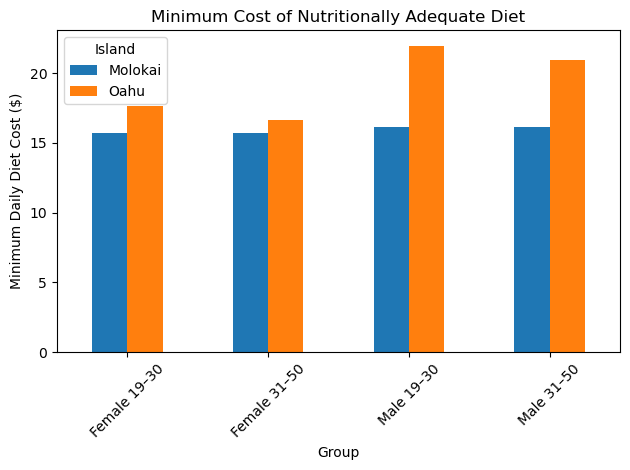

In [78]:
cost_pivot = cost_df.pivot(index="Group", columns="Island", values="Cost")

import matplotlib.pyplot as plt

cost_pivot.plot.bar()

plt.ylabel("Minimum Daily Diet Cost ($)")
plt.title("Minimum Cost of Nutritionally Adequate Diet")
plt.xticks(rotation=45)
plt.legend(title="Island")

plt.tight_layout()
plt.show()

### Optimal diet foods

In [81]:
diet_results = {}

for group in age_sex_groups:

    molokai = subsistence_solver(molokai_food_df, dri_df, group)
    oahu = subsistence_solver(oahu_food_df, dri_df, group)

    diet_results[(group, "Molokai")] = molokai.Diet
    diet_results[(group, "Oahu")] = oahu.Diet

diet_df_list = []

for (group, island), diet in diet_results.items():

    temp = diet.reset_index()
    temp.columns = ["Food", "Quantity"]

    temp["Group"] = group
    temp["Island"] = island

    diet_df_list.append(temp)

diet_df = pd.concat(diet_df_list)

diet_df["Share"] = diet_df.groupby(["Group","Island"])["Quantity"].transform(
    lambda x: x / x.sum()
)

diet_df["Label"] = diet_df["Group"] + " - " + diet_df["Island"]

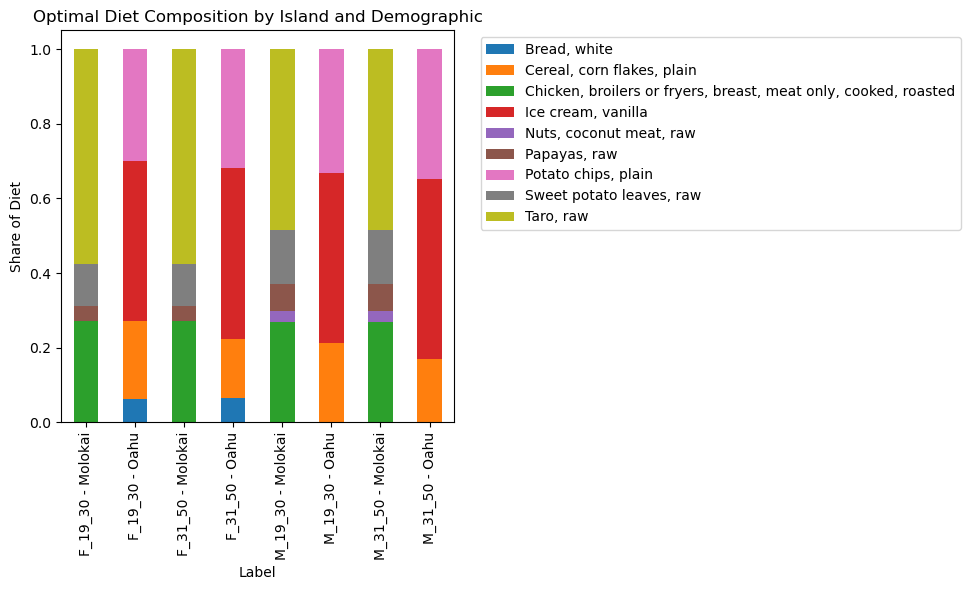

In [85]:
diet_pivot = diet_df.pivot_table(
    index="Label",
    columns="Food",
    values="Share",
    fill_value=0)

diet_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6))

plt.ylabel("Share of Diet")
plt.title("Optimal Diet Composition by Island and Demographic")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()